Loading drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing model:

In [ ]:
import pickle

with open("/content/drive/My Drive/emoji_project/datasets/split_data/data_split.pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Loaded!", len(X_train), "training samples")

Loaded! 180264 training samples


TF-IDF vectorization:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (180264, 10000)
Testing matrix shape: (45067, 10000)


Training the model:

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced', max_iter=500, tol=1e-2)
model.fit(X_train_tfidf, y_train)

print("Model trained!")

Model trained!


Creating a classification report:

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       blush       0.37      0.32      0.34      4568
     flushed       0.37      0.57      0.45      2067
        grin       0.38      0.36      0.37      2964
  heart_eyes       0.63      0.53      0.58      7919
     relaxed       0.30      0.34      0.32      2143
       smirk       0.32      0.43      0.37      3000
         sob       0.59      0.45      0.51      9989
       weary       0.40      0.39      0.40      5344
        wink       0.34      0.44      0.38      3679
         yum       0.41      0.52      0.46      3394

    accuracy                           0.44     45067
   macro avg       0.41      0.44      0.42     45067
weighted avg       0.46      0.44      0.45     45067



With this report, we can see the model is performing best at the heart_eyes and sob emoji. This is most likely because there's a lot of data that involves these emojis. relaxed and blush are the worst performing emojis.

We can use a confusion matrix to see which emojis are getting mixed up:

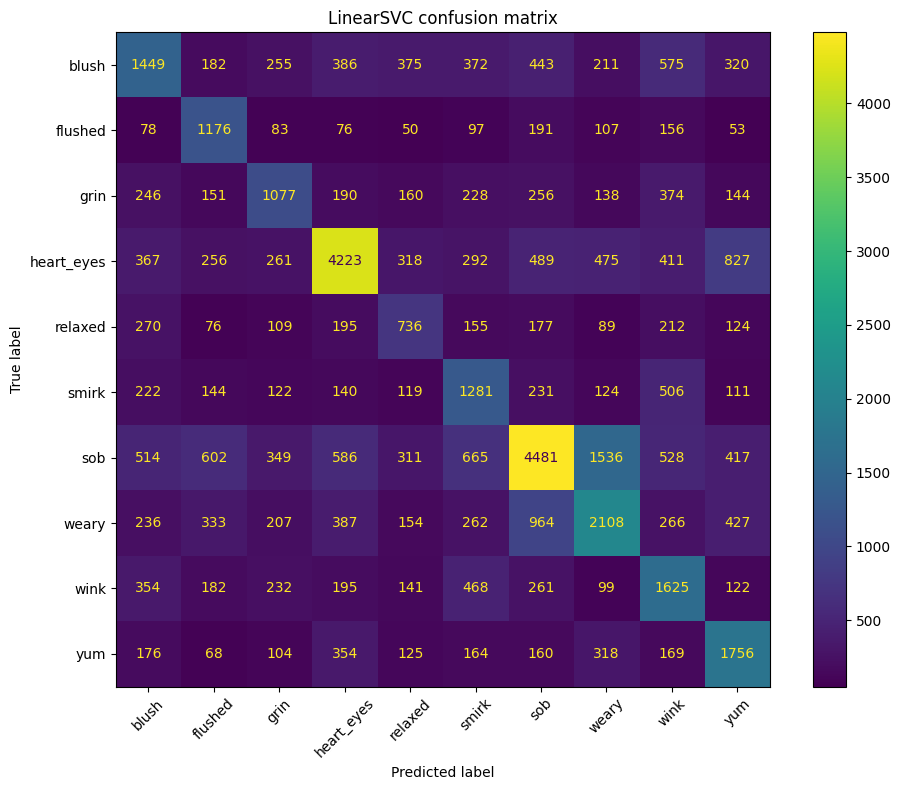

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
plt.title('LinearSVC confusion matrix')
plt.tight_layout()
plt.show()

According to the confusion matrix, sob was predicted as smirk 665 times and as weary 165 times, all negative/intense emotions.

Weary was also predicted as sob 964 time, showing that the model struggles to tell tiredness from sadness

Blush was predicted as wink 575 times and Smirk was predicted as wink 506 times, which makes sense because these are flirty/shy emotions and are easy to mix up.

Let's try it with a different maximum feature limit: 50000

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (180264, 10000)
Testing matrix shape: (45067, 10000)


Train the model:

In [ ]:
from sklearn.svm import LinearSVC
model = LinearSVC(class_weight='balanced', max_iter=500, tol=1e-2)
model.fit(X_train_tfidf, y_train)

print("Model trained!")

Model trained!


Evaluating the model with the classification report again:

In [ ]:
from sklearn.metrics import classification_report


y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       blush       0.37      0.32      0.34      4568
     flushed       0.37      0.57      0.45      2067
        grin       0.38      0.36      0.37      2964
  heart_eyes       0.63      0.53      0.58      7919
     relaxed       0.30      0.34      0.32      2143
       smirk       0.32      0.43      0.37      3000
         sob       0.59      0.45      0.51      9989
       weary       0.40      0.39      0.40      5344
        wink       0.34      0.44      0.38      3679
         yum       0.41      0.52      0.46      3394

    accuracy                           0.44     45067
   macro avg       0.41      0.44      0.42     45067
weighted avg       0.46      0.44      0.45     45067



This didn't do much, the overall accuracy only increased by one percent. This is probably because the model already learned everything from the structure. We can make the model less strict by changing the value for the C parameter.

Confusion Matrix:

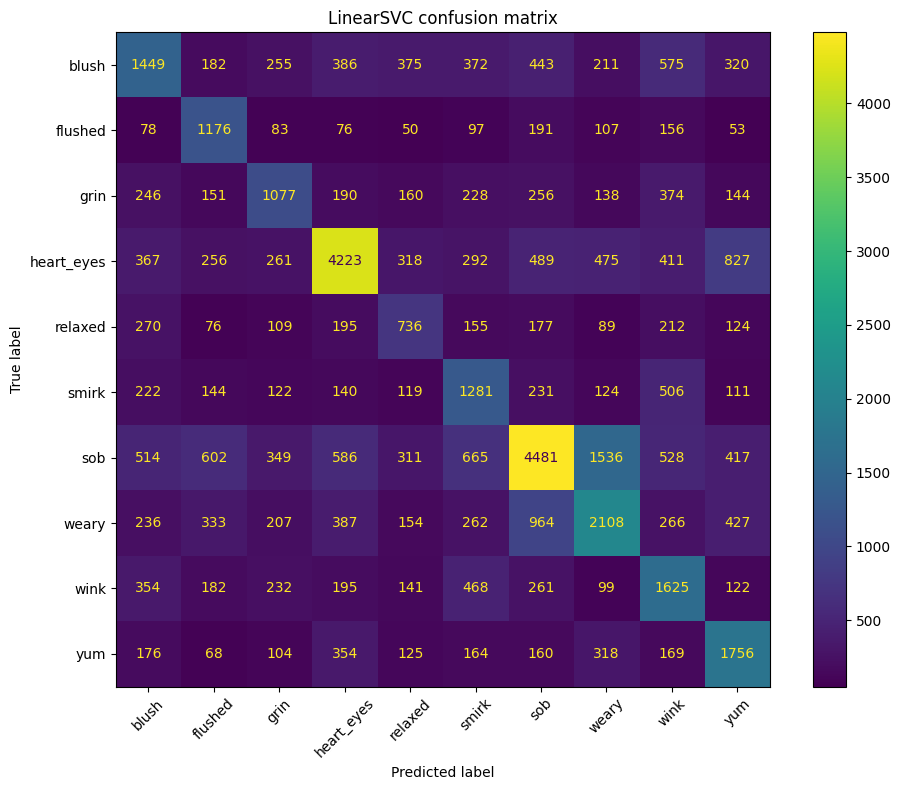

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
plt.title('LinearSVC confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced', max_iter=1000, tol=1e-3, C=0.1)
model.fit(X_train_tfidf, y_train)

print("Model trained!")

Model trained!


Create classification report:

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       blush       0.36      0.31      0.34      4568
     flushed       0.40      0.55      0.46      2067
        grin       0.42      0.34      0.38      2964
  heart_eyes       0.61      0.55      0.58      7919
     relaxed       0.32      0.33      0.33      2143
       smirk       0.32      0.41      0.36      3000
         sob       0.58      0.45      0.51      9989
       weary       0.40      0.41      0.40      5344
        wink       0.33      0.46      0.39      3679
         yum       0.41      0.52      0.46      3394

    accuracy                           0.44     45067
   macro avg       0.41      0.43      0.42     45067
weighted avg       0.46      0.44      0.45     45067



It's still at 44% accuracy. This is esentially because the model has plateaued, meaning that the model has learned has learned as much as it possibly can from the data given.